# Tema 2 - Descripción de Sistemas Dinámicos

**Fundamentos de Control - GIERM**

---

## Objetivos de aprendizaje

- Obtener el modelo matemático (EDO) de sistemas mecánicos, eléctricos, hidráulicos y térmicos a partir de leyes físicas
- Linealizar ecuaciones diferenciales no lineales alrededor de un punto de equilibrio
- Obtener la función de transferencia $G(s)$ de un sistema a partir de su EDO linealizada
- Interpretar y reducir diagramas de bloques usando las reglas de álgebra de bloques
- Relacionar la respuesta temporal de un sistema con su función de transferencia
- Clasificar y resolver los tipos de problemas más frecuentes en exámenes

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from matplotlib.lines import Line2D
import scipy.signal as signal
from scipy.integrate import odeint

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['figure.dpi'] = 100

COLOR_PRINCIPAL = '#2171b5'   # azul - curvas principales
COLOR_RECTA = '#cb181d'       # rojo - aproximaciones, límites
COLOR_PUNTO = '#238b45'       # verde - puntos de equilibrio, resultados
COLOR_AUX = '#ff7f00'         # naranja - curvas auxiliares
COLOR_AUX2 = '#6a3d9a'        # púrpura - curvas secundarias

print('Configuración lista.')

Configuración lista.


---

## 1. Introducción: ¿Qué es un modelo matemático?

Un **modelo matemático** es una descripción del comportamiento dinámico de un sistema físico mediante ecuaciones diferenciales. El objetivo es predecir cómo evoluciona la salida $y(t)$ ante una entrada $u(t)$.

El procedimiento general es:

1. **Identificar las variables**: entrada $u(t)$, salida $y(t)$, variables de estado
2. **Aplicar leyes físicas** (Newton, Kirchhoff, balances de masa/energía) para obtener la **EDO**
3. **Linealizar** si la EDO es no lineal
4. **Aplicar Laplace** para obtener la **función de transferencia** $G(s)$

$$\boxed{G(s) = \frac{Y(s)}{U(s)}}$$

donde $Y(s)$ y $U(s)$ son las transformadas de Laplace de la salida y la entrada, respectivamente, con condiciones iniciales nulas.

---

## 2. Modelado físico de sistemas

### 2.1 Sistema mecánico traslacional (2ª Ley de Newton)

La ley fundamental es $\sum F = m \cdot a$. Para un sistema **masa-resorte-amortiguador**:

- **Masa** $m$: fuerza de inercia $F_m = m \ddot{x}$
- **Amortiguador** $b$: fuerza de fricción viscosa $F_b = b \dot{x}$
- **Resorte** $k$: fuerza elástica $F_k = k x$
- **Entrada**: fuerza externa $F(t)$

Aplicando Newton ($\sum F = m a$) con $x(t)$ como desplazamiento desde el equilibrio:

$$F(t) - b\dot{x} - kx = m\ddot{x}$$

$$\boxed{m\ddot{x}(t) + b\dot{x}(t) + kx(t) = F(t)}$$

**Ejemplo:** $m = 2$ kg, $b = 3$ N$\cdot$s/m, $k = 5$ N/m

$$2\ddot{x} + 3\dot{x} + 5x = F(t)$$

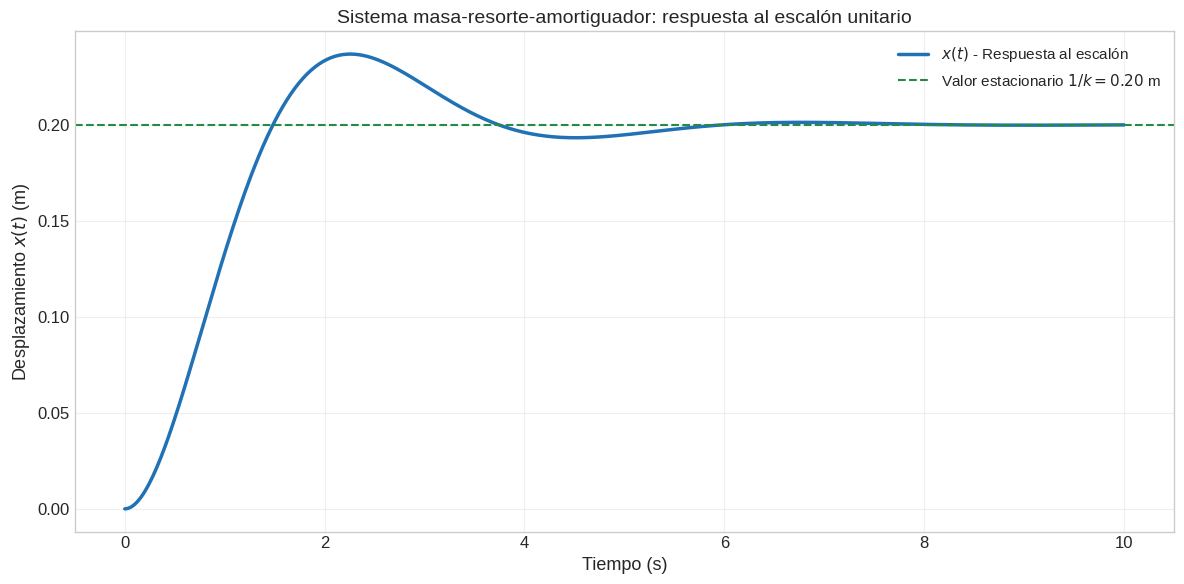

In [2]:
# Respuesta del sistema masa-resorte-amortiguador ante escalón unitario
m, b, k = 2, 3, 5
num = [1]
den = [m, b, k]
sys_mra = signal.TransferFunction(num, den)
t, y = signal.step(sys_mra, T=np.linspace(0, 10, 500))

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(t, y, color=COLOR_PRINCIPAL, lw=2.5, label=r'$x(t)$ - Respuesta al escalón')
ax.axhline(y=1/k, color=COLOR_PUNTO, ls='--', lw=1.5, label=f'Valor estacionario $1/k = {1/k:.2f}$ m')
ax.set_xlabel('Tiempo (s)')
ax.set_ylabel(r'Desplazamiento $x(t)$ (m)')
ax.set_title('Sistema masa-resorte-amortiguador: respuesta al escalón unitario')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2.2 Sistema eléctrico (Leyes de Kirchhoff)

Para circuitos eléctricos se aplican las **leyes de Kirchhoff**:

- **LKV** (ley de tensiones): la suma de caídas de tensión en un lazo cerrado es cero
- **LKC** (ley de corrientes): la suma de corrientes en un nodo es cero

Componentes y sus relaciones $v$-$i$:

| Componente | Relación | Energía |
|-----------|----------|---------|
| Resistencia $R$ | $v_R = R \cdot i$ | Disipa |
| Inductancia $L$ | $v_L = L \dfrac{di}{dt}$ | Almacena (campo magnético) |
| Condensador $C$ | $i_C = C \dfrac{dv_C}{dt}$ | Almacena (campo eléctrico) |

**Ejemplo: Circuito RLC serie** con entrada $v_{in}(t)$ y salida $v_C(t)$:

Aplicando LKV al lazo:

$$v_{in}(t) = v_R + v_L + v_C = R \cdot i + L\frac{di}{dt} + v_C$$

Como $i = C\dfrac{dv_C}{dt}$, sustituimos:

$$v_{in} = RC\frac{dv_C}{dt} + LC\frac{d^2v_C}{dt^2} + v_C$$

$$\boxed{LC\ddot{v}_C(t) + RC\dot{v}_C(t) + v_C(t) = v_{in}(t)}$$

**Ejemplo numérico:** $R = 10\;\Omega$, $L = 0.5$ H, $C = 0.01$ F

$$0.005\ddot{v}_C + 0.1\dot{v}_C + v_C = v_{in}(t)$$

### 2.3 Sistema hidráulico (Balance de masa)

Para un **tanque** de sección transversal $A$, con caudal de entrada $q_{in}(t)$ y caudal de salida $q_{out}(t)$, la variable de estado es el nivel $h(t)$.

**Ley de conservación de masa** (líquido incompresible):

$$A\frac{dh}{dt} = q_{in}(t) - q_{out}(t)$$

Si la salida es por una válvula con resistencia hidráulica $R_h$:

$$q_{out} = \frac{h}{R_h}$$

Sustituyendo:

$$\boxed{AR_h\frac{dh}{dt} + h(t) = R_h \cdot q_{in}(t)}$$

Esta es una EDO de **primer orden** (sistema de un tanque). La constante de tiempo es $\tau = AR_h$.

**Caso no lineal:** Si la salida es por un orificio (ley de Torricelli):

$$q_{out} = c\sqrt{h} \quad \implies \quad A\frac{dh}{dt} = q_{in} - c\sqrt{h}$$

Esta EDO es **no lineal** debido al término $\sqrt{h}$ y necesitará **linealización**.

### Resumen de leyes físicas por dominio

| Dominio | Ley fundamental | Variables de flujo | Variables de esfuerzo |
|:---:|:---:|:---:|:---:|
| Mecánico traslacional | Newton: $F = ma$ | Velocidad $v$ | Fuerza $F$ |
| Mecánico rotacional | Newton: $T = I\alpha$ | Velocidad angular $\omega$ | Par $T$ |
| Eléctrico | Kirchhoff: LKV + LKC | Corriente $i$ | Tensión $v$ |
| Hidráulico | Balance de masa | Caudal $q$ | Presión / nivel $h$ |
| Térmico | Balance de energía | Flujo de calor $q$ | Temperatura $T$ |

### 2.4 Sistema térmico (Balance de energía)

Para un cuerpo de masa $m$, calor específico $c_p$ y temperatura $T(t)$, sometido a una fuente de calor $q_{in}(t)$ y pérdidas por convección:

**Balance de energía:**

$$mc_p\frac{dT}{dt} = q_{in}(t) - \frac{T - T_{amb}}{R_t}$$

donde $R_t$ es la **resistencia térmica** (K/W) y $T_{amb}$ la temperatura ambiente.

Definiendo $\theta(t) = T(t) - T_{amb}$ (incremento de temperatura):

$$\boxed{mc_p R_t \frac{d\theta}{dt} + \theta(t) = R_t \cdot q_{in}(t)}$$

Nuevamente un sistema de **primer orden** con constante de tiempo $\tau = mc_pR_t$.

**Analogía eléctrica:**

| Térmico | Eléctrico |
|---------|-----------|
| Temperatura $T$ | Tensión $v$ |
| Flujo de calor $q$ | Corriente $i$ |
| Capacidad térmica $C_t = mc_p$ | Capacitancia $C$ |
| Resistencia térmica $R_t$ | Resistencia $R$ |

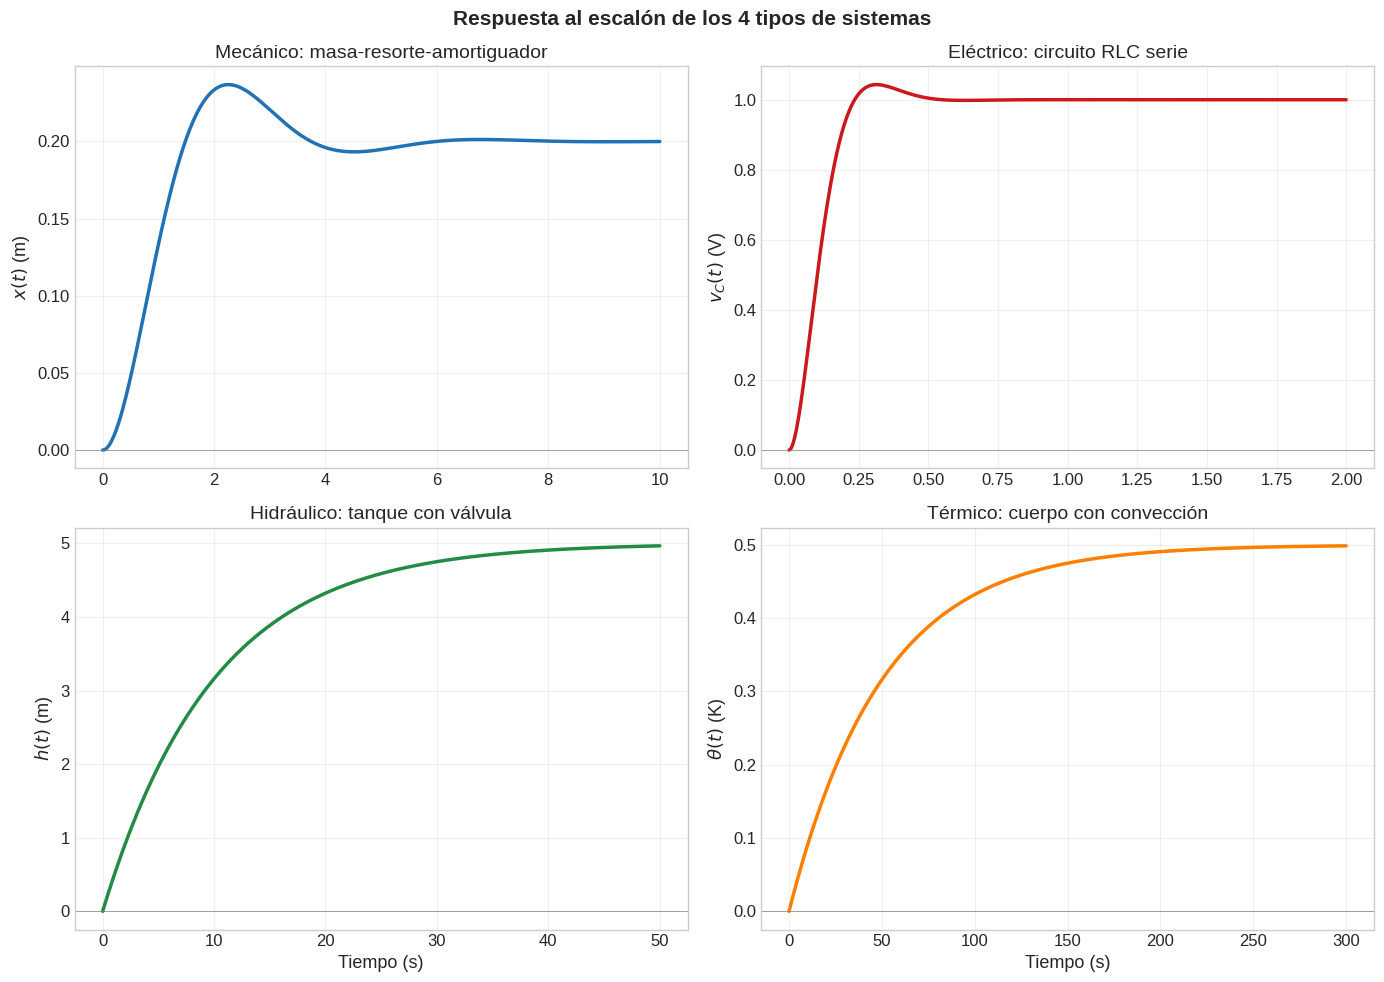

In [3]:
# Comparativa de respuestas: 4 tipos de sistemas (todos de 1er o 2do orden)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Mecánico (2do orden)
m, b, k = 2, 3, 5
sys1 = signal.TransferFunction([1], [m, b, k])
t1, y1 = signal.step(sys1, T=np.linspace(0, 10, 500))
axes[0, 0].plot(t1, y1, color=COLOR_PRINCIPAL, lw=2.5)
axes[0, 0].set_title('Mecánico: masa-resorte-amortiguador')
axes[0, 0].set_ylabel(r'$x(t)$ (m)')

# Eléctrico (2do orden)
R, L, C = 10, 0.5, 0.01
sys2 = signal.TransferFunction([1], [L*C, R*C, 1])
t2, y2 = signal.step(sys2, T=np.linspace(0, 2, 500))
axes[0, 1].plot(t2, y2, color=COLOR_RECTA, lw=2.5)
axes[0, 1].set_title('Eléctrico: circuito RLC serie')
axes[0, 1].set_ylabel(r'$v_C(t)$ (V)')

# Hidráulico (1er orden)
A_tank, Rh = 2, 5
tau_h = A_tank * Rh
sys3 = signal.TransferFunction([Rh], [tau_h, 1])
t3, y3 = signal.step(sys3, T=np.linspace(0, 50, 500))
axes[1, 0].plot(t3, y3, color=COLOR_PUNTO, lw=2.5)
axes[1, 0].set_title('Hidráulico: tanque con válvula')
axes[1, 0].set_ylabel(r'$h(t)$ (m)')
axes[1, 0].set_xlabel('Tiempo (s)')

# Térmico (1er orden)
mc_p, Rt = 100, 0.5
tau_t = mc_p * Rt
sys4 = signal.TransferFunction([Rt], [tau_t, 1])
t4, y4 = signal.step(sys4, T=np.linspace(0, 300, 500))
axes[1, 1].plot(t4, y4, color=COLOR_AUX, lw=2.5)
axes[1, 1].set_title('Térmico: cuerpo con convección')
axes[1, 1].set_ylabel(r'$\theta(t)$ (K)')
axes[1, 1].set_xlabel('Tiempo (s)')

for ax in axes.flat:
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='gray', lw=0.5)

fig.suptitle('Respuesta al escalón de los 4 tipos de sistemas', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 3. Linealización alrededor del punto de equilibrio

### 3.1 Concepto general

Muchos sistemas reales son **no lineales**. Para poder aplicar la transformada de Laplace y obtener funciones de transferencia, necesitamos **linealizar** la EDO alrededor de un **punto de equilibrio** (también llamado punto de operación).

**Procedimiento general de linealización:**

1. Escribir la EDO no lineal: $\dot{x} = f(x, u)$
2. Encontrar el **punto de equilibrio** $(x_{eq}, u_{eq})$ donde $f(x_{eq}, u_{eq}) = 0$
3. Definir **variables incrementales**: $\delta x = x - x_{eq}$, $\delta u = u - u_{eq}$
4. Expandir en **serie de Taylor** y quedarse con los términos lineales:

$$\boxed{\delta\dot{x} \approx \left.\frac{\partial f}{\partial x}\right|_{eq} \delta x + \left.\frac{\partial f}{\partial u}\right|_{eq} \delta u}$$

### 3.2 Ejemplo completo: Péndulo con fricción

Consideremos un péndulo de momento de inercia $I$, fricción viscosa $B$, masa $m$, longitud $l$ y par externo $T$:

$$I\ddot{\varphi} + B\dot{\varphi} + mgl\sin(\varphi) = T$$

**Paso 1: Punto de equilibrio.** En equilibrio $\ddot{\varphi} = \dot{\varphi} = 0$:

$$mgl\sin(\varphi_{eq}) = T_{eq} \quad \implies \quad \sin(\varphi_{eq}) = \frac{T_{eq}}{mgl}$$

**Paso 2: Desarrollo de Taylor de $\sin(\varphi)$ alrededor de $\varphi_{eq}$:**

$$\sin(\varphi) \approx \sin(\varphi_{eq}) + \cos(\varphi_{eq})\cdot(\varphi - \varphi_{eq})$$

**Paso 3: Variables incrementales.** Definimos $\delta\varphi = \varphi - \varphi_{eq}$ y $\delta T = T - T_{eq}$:

$$I\delta\ddot{\varphi} + B\delta\dot{\varphi} + mgl\left[\sin(\varphi_{eq}) + \cos(\varphi_{eq})\cdot\delta\varphi\right] = T_{eq} + \delta T$$

Como $mgl\sin(\varphi_{eq}) = T_{eq}$, estos términos se cancelan:

$$\boxed{I\delta\ddot{\varphi} + B\delta\dot{\varphi} + mgl\cos(\varphi_{eq})\cdot\delta\varphi = \delta T}$$

**Caso particular:** para $\varphi_{eq} = 0$ (posición vertical inferior), $T_{eq} = 0$:

$$I\delta\ddot{\varphi} + B\delta\dot{\varphi} + mgl\cdot\delta\varphi = \delta T$$

ya que $\cos(0) = 1$. Esto es una EDO lineal de 2º orden idéntica en estructura al sistema masa-resorte-amortiguador.

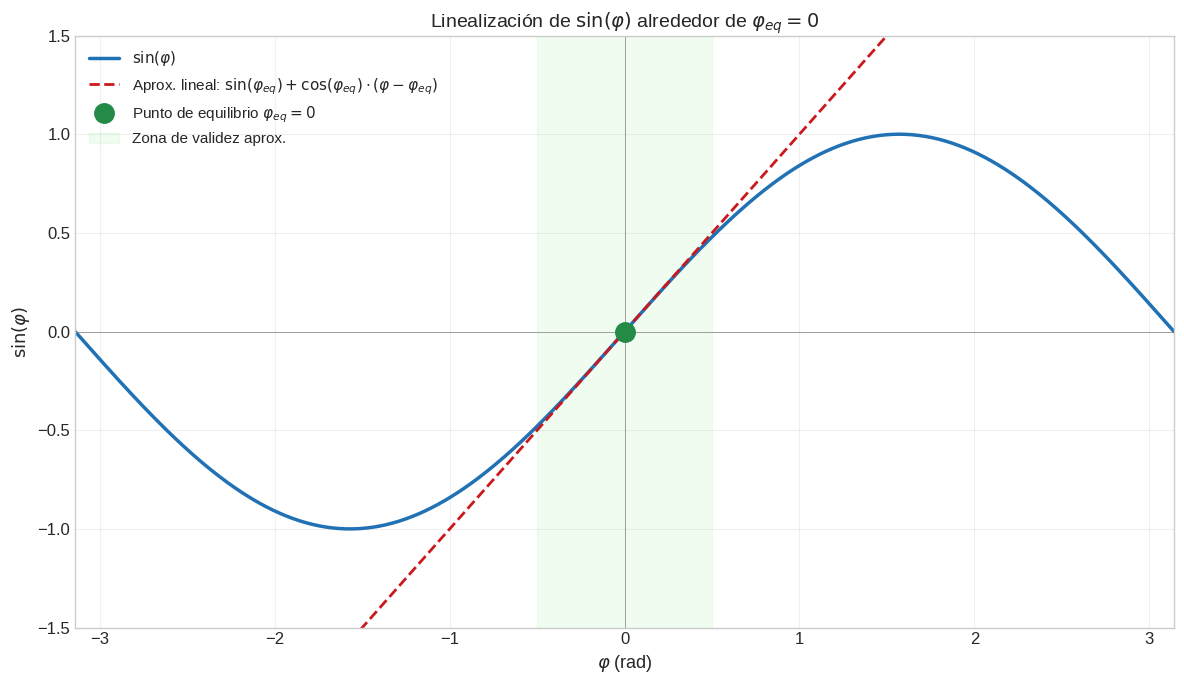

In [4]:
# Gráfica: sin(φ) vs su aproximación lineal alrededor de φ_eq = 0
phi = np.linspace(-np.pi, np.pi, 500)
phi_eq = 0

# Función original y aproximación lineal
sin_phi = np.sin(phi)
lin_approx = np.sin(phi_eq) + np.cos(phi_eq) * (phi - phi_eq)  # = φ para φ_eq=0

fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(phi, sin_phi, color=COLOR_PRINCIPAL, lw=2.5, label=r'$\sin(\varphi)$')
ax.plot(phi, lin_approx, color=COLOR_RECTA, lw=2, ls='--',
        label=r'Aprox. lineal: $\sin(\varphi_{eq}) + \cos(\varphi_{eq})\cdot(\varphi - \varphi_{eq})$')
ax.plot(phi_eq, np.sin(phi_eq), 'o', color=COLOR_PUNTO, ms=14, zorder=5,
        label=r'Punto de equilibrio $\varphi_{eq} = 0$')

# Zona de validez de la linealización
ax.axvspan(-0.5, 0.5, alpha=0.12, color='lightgreen', label='Zona de validez aprox.')
ax.axhline(y=0, color='gray', lw=0.5)
ax.axvline(x=0, color='gray', lw=0.5)

ax.set_xlabel(r'$\varphi$ (rad)')
ax.set_ylabel(r'$\sin(\varphi)$')
ax.set_title(r'Linealización de $\sin(\varphi)$ alrededor de $\varphi_{eq} = 0$')
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(-1.5, 1.5)
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## 4. Característica estática

La **característica estática** relaciona la salida en régimen permanente $Y_{eq}$ con la entrada en régimen permanente $U_{eq}$. Se obtiene igualando a cero todas las derivadas en la EDO.

Para el péndulo: $mgl\sin(\varphi_{eq}) = T_{eq}$

$$\varphi_{eq} = \arcsin\left(\frac{T_{eq}}{mgl}\right)$$

Esta relación $\varphi_{eq}(T_{eq})$ es la **curva estática**. La pendiente de esta curva en un punto de operación da la **ganancia estática** del sistema linealizado.

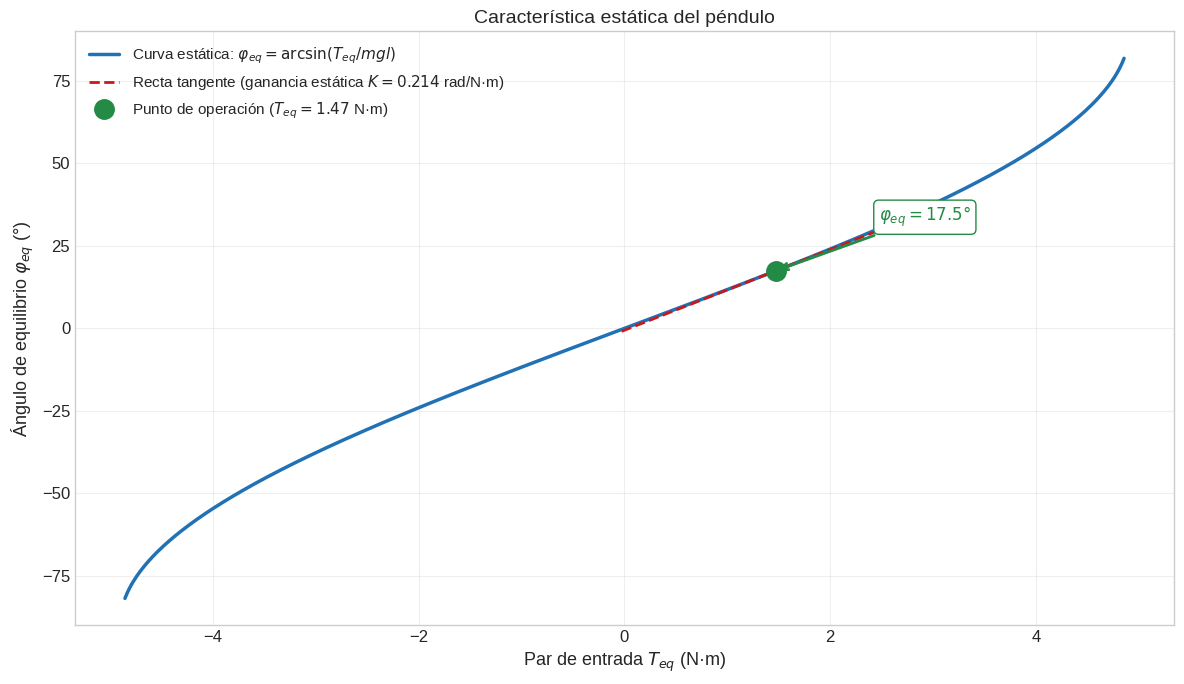

In [5]:
# Característica estática del péndulo: φ_eq vs T_eq
m_pend, g, l_pend = 1, 9.81, 0.5
mgl = m_pend * g * l_pend

T_eq = np.linspace(-mgl * 0.99, mgl * 0.99, 500)
phi_eq_vals = np.arcsin(T_eq / mgl)

# Punto de operación elegido
T_op = 0.3 * mgl
phi_op = np.arcsin(T_op / mgl)

# Recta tangente (ganancia estática local)
# dφ/dT = 1/(mgl·cos(φ_eq))
K_est = 1 / (mgl * np.cos(phi_op))
T_tang = np.linspace(T_op - 1.5, T_op + 1.5, 100)
phi_tang = phi_op + K_est * (T_tang - T_op)

fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(T_eq, np.degrees(phi_eq_vals), color=COLOR_PRINCIPAL, lw=2.5,
        label=r'Curva estática: $\varphi_{eq} = \arcsin(T_{eq}/mgl)$')
ax.plot(T_tang, np.degrees(phi_tang), color=COLOR_RECTA, lw=2, ls='--',
        label=f'Recta tangente (ganancia estática $K = {K_est:.3f}$ rad/N·m)')
ax.plot(T_op, np.degrees(phi_op), 'o', color=COLOR_PUNTO, ms=14, zorder=5,
        label=f'Punto de operación ($T_{{eq}}={T_op:.2f}$ N·m)')

ax.annotate(f'$\\varphi_{{eq}} = {np.degrees(phi_op):.1f}°$',
            xy=(T_op, np.degrees(phi_op)),
            xytext=(T_op + 1, np.degrees(phi_op) + 15),
            fontsize=12, color=COLOR_PUNTO, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_PUNTO, lw=2),
            bbox=dict(boxstyle='round', facecolor='white', edgecolor=COLOR_PUNTO))

ax.set_xlabel(r'Par de entrada $T_{eq}$ (N·m)')
ax.set_ylabel(r'Ángulo de equilibrio $\varphi_{eq}$ (°)')
ax.set_title('Característica estática del péndulo')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## 5. Función de transferencia $G(s)$

### 5.1 Definición y obtención

La **función de transferencia** se obtiene aplicando la transformada de Laplace a la EDO linealizada con **condiciones iniciales nulas**:

$$\boxed{G(s) = \frac{Y(s)}{U(s)}}$$

**Recordatorio de propiedades de Laplace:**

| Dominio temporal | Dominio de Laplace |
|-----------------|-------------------|
| $y(t)$ | $Y(s)$ |
| $\dot{y}(t)$ | $sY(s)$ |
| $\ddot{y}(t)$ | $s^2Y(s)$ |
| $y^{(n)}(t)$ | $s^nY(s)$ |

### 5.2 Ejemplo: Circuito RLC serie

Partimos de la EDO del circuito RLC (sección 2.2):

$$LC\ddot{v}_C + RC\dot{v}_C + v_C = v_{in}$$

**Paso 1:** Aplicar Laplace (c.i. nulas):

$$LCs^2V_C(s) + RCsV_C(s) + V_C(s) = V_{in}(s)$$

**Paso 2:** Factorizar $V_C(s)$:

$$V_C(s)\left[LCs^2 + RCs + 1\right] = V_{in}(s)$$

**Paso 3:** Despejar la función de transferencia:

$$\boxed{G(s) = \frac{V_C(s)}{V_{in}(s)} = \frac{1}{LCs^2 + RCs + 1}}$$

**Con valores numéricos** ($R = 10\;\Omega$, $L = 0.5$ H, $C = 0.01$ F):

$$G(s) = \frac{1}{0.005s^2 + 0.1s + 1} = \frac{200}{s^2 + 20s + 200}$$

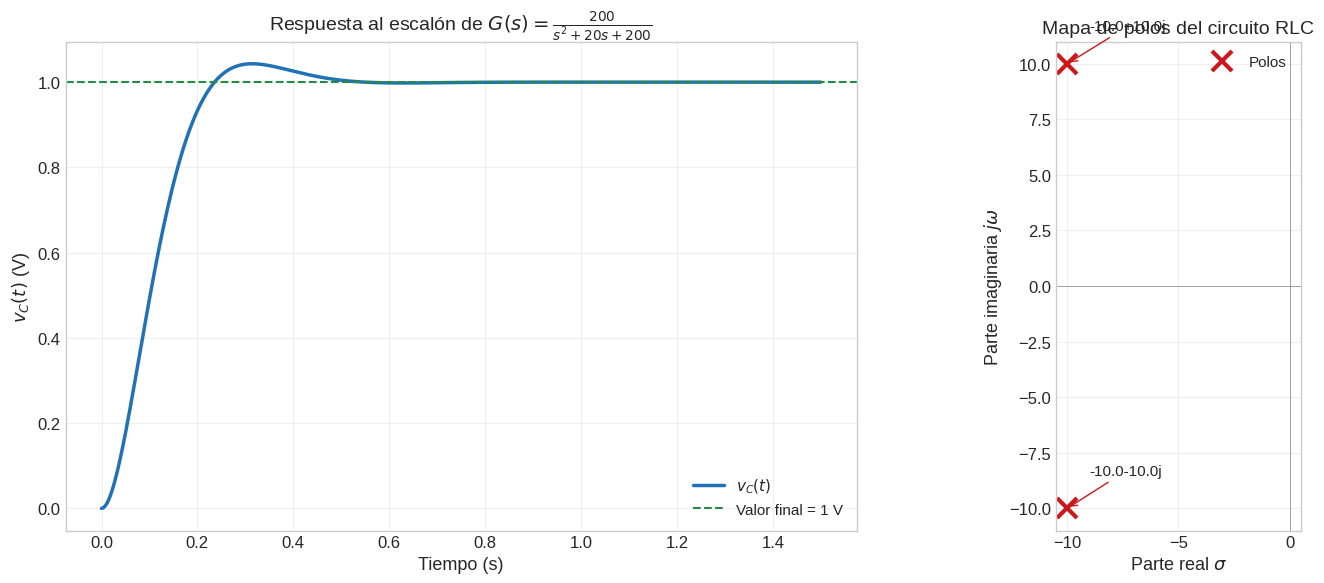

In [6]:
# Respuesta al escalón del circuito RLC: G(s) = 200/(s^2 + 20s + 200)
num_rlc = [200]
den_rlc = [1, 20, 200]
sys_rlc = signal.TransferFunction(num_rlc, den_rlc)
t_rlc, y_rlc = signal.step(sys_rlc, T=np.linspace(0, 1.5, 500))

# Polos del sistema
polos = np.roots(den_rlc)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Respuesta al escalón
axes[0].plot(t_rlc, y_rlc, color=COLOR_PRINCIPAL, lw=2.5, label=r'$v_C(t)$')
axes[0].axhline(y=1.0, color=COLOR_PUNTO, ls='--', lw=1.5, label='Valor final = 1 V')
axes[0].set_xlabel('Tiempo (s)')
axes[0].set_ylabel(r'$v_C(t)$ (V)')
axes[0].set_title(r'Respuesta al escalón de $G(s) = \frac{200}{s^2+20s+200}$')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Mapa de polos y ceros
axes[1].plot(polos.real, polos.imag, 'x', color=COLOR_RECTA, ms=14, mew=3, label='Polos')
axes[1].axhline(y=0, color='gray', lw=0.5)
axes[1].axvline(x=0, color='gray', lw=0.5)
for p in polos:
    axes[1].annotate(f'{p:.1f}', xy=(p.real, p.imag),
                     xytext=(p.real + 1, p.imag + 1.5), fontsize=11,
                     arrowprops=dict(arrowstyle='->', color=COLOR_RECTA))
axes[1].set_xlabel(r'Parte real $\sigma$')
axes[1].set_ylabel(r'Parte imaginaria $j\omega$')
axes[1].set_title('Mapa de polos del circuito RLC')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

### 5.4 Metodología: de la EDO a la función de transferencia

**Pasos para obtener $G(s)$ desde un sistema físico:**

1. **Identificar** entrada $u(t)$ y salida $y(t)$
2. **Aplicar leyes físicas** para obtener la EDO
3. Si la EDO es **no lineal**: linealizar alrededor de $(y_{eq}, u_{eq})$
4. **Sustituir** cada derivada por la potencia correspondiente de $s$:
   - $y \to Y(s)$, $\dot{y} \to sY(s)$, $\ddot{y} \to s^2Y(s)$
5. **Agrupar** $Y(s)$ a un lado y $U(s)$ al otro
6. **Despejar** $G(s) = Y(s)/U(s)$
7. **Verificar**: calcular $G(0)$ (ganancia estática) y comprobar que los polos tienen parte real negativa (estabilidad)

### 5.3 Función de transferencia del péndulo linealizado

Partiendo de la EDO linealizada ($\varphi_{eq} = 0$):

$$I\delta\ddot{\varphi} + B\delta\dot{\varphi} + mgl\cdot\delta\varphi = \delta T$$

Aplicando Laplace:

$$Is^2\Phi(s) + Bs\Phi(s) + mgl\Phi(s) = \Delta T(s)$$

$$\boxed{G(s) = \frac{\Phi(s)}{\Delta T(s)} = \frac{1}{Is^2 + Bs + mgl}}$$

**Con valores numéricos:** $I = 0.5$ kg$\cdot$m$^2$, $B = 0.2$ N$\cdot$m$\cdot$s/rad, $m = 1$ kg, $g = 9.81$ m/s$^2$, $l = 0.5$ m:

$$G(s) = \frac{1}{0.5s^2 + 0.2s + 4.905} = \frac{2}{s^2 + 0.4s + 9.81}$$

### 6.3 Reglas adicionales: mover puntos de bifurcación y sumadores

Al reducir diagramas complejos, a veces es necesario **mover** puntos de bifurcación o sumadores:

| Operación | Compensación necesaria |
|:---:|:---:|
| Mover bifurcación **antes** de un bloque $G$ | Añadir bloque $G$ en la rama movida |
| Mover bifurcación **después** de un bloque $G$ | Añadir bloque $1/G$ en la rama movida |
| Mover sumador **antes** de un bloque $G$ | Añadir bloque $G$ en la rama movida |
| Mover sumador **después** de un bloque $G$ | Añadir bloque $1/G$ en la rama movida |

**Error frecuente:** olvidar la compensación al mover elementos $\to$ resultado incorrecto.

---

## 6. Diagramas de bloques

### 6.1 Elementos básicos

Un diagrama de bloques representa gráficamente las relaciones entre las variables de un sistema de control:

- **Bloque**: operación de transferencia $G(s)$
- **Sumador**: punto de suma/resta de señales ($\oplus / \ominus$)
- **Bifurcación**: punto donde una señal se divide en dos caminos

### 6.2 Reglas de reducción

| Configuración | Diagrama | Equivalente |
|:---:|:---:|:---:|
| **Serie** | $R \to G_1 \to G_2 \to Y$ | $G_{eq} = G_1 \cdot G_2$ |
| **Paralelo** | $R \to G_1 + G_2 \to Y$ | $G_{eq} = G_1 + G_2$ |
| **Realimentación negativa** | Lazo con $G$ directa y $H$ retorno | $G_{eq} = \dfrac{G}{1 + GH}$ |
| **Realimentación positiva** | Lazo con $G$ directa y $H$ retorno | $G_{eq} = \dfrac{G}{1 - GH}$ |
| **Realimentación unitaria** | $H = 1$ | $G_{eq} = \dfrac{G}{1 + G}$ |

$$\boxed{G_{eq,\text{feedback}} = \frac{G}{1 + GH}}$$

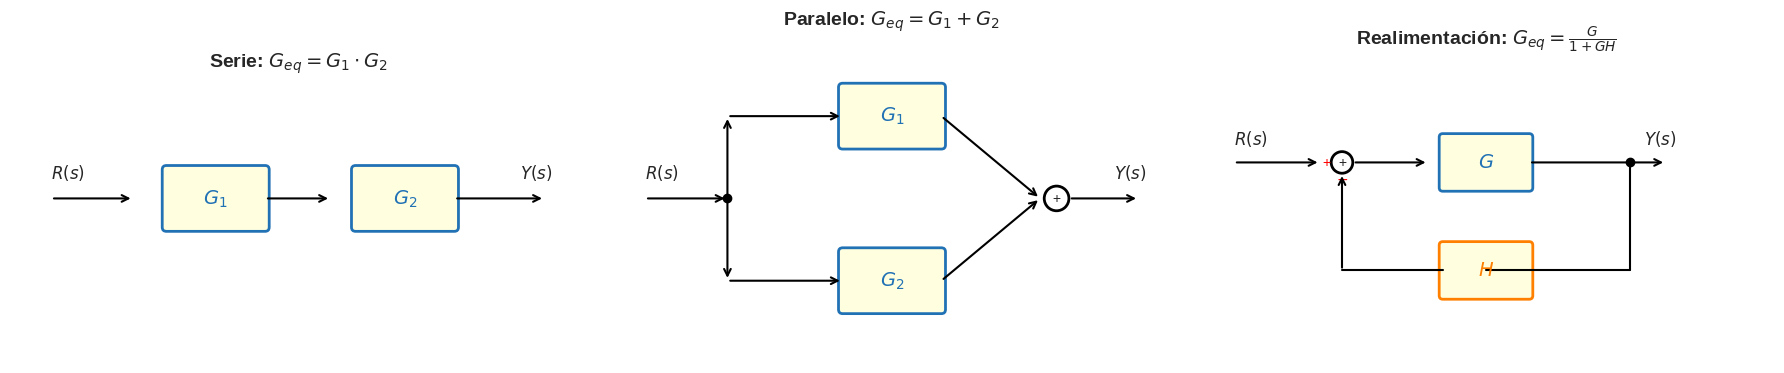

In [7]:
# Diagramas de bloques: Serie, Paralelo y Realimentación
def draw_block(ax, x, y, w, h, text, color=COLOR_PRINCIPAL):
    """Dibuja un bloque rectangular con texto centrado."""
    rect = FancyBboxPatch((x - w/2, y - h/2), w, h,
                          boxstyle="round,pad=0.05", facecolor='lightyellow',
                          edgecolor=color, lw=2)
    ax.add_patch(rect)
    ax.text(x, y, text, ha='center', va='center', fontsize=14, fontweight='bold', color=color)

def draw_sumador(ax, x, y, radius=0.15, signs=None):
    """Dibuja un sumador (círculo con +/-)."""
    circle = plt.Circle((x, y), radius, fill=False, edgecolor='black', lw=2)
    ax.add_patch(circle)
    ax.text(x, y, '+', ha='center', va='center', fontsize=10)
    if signs:
        for pos, sign in signs.items():
            dx, dy = {'left': (-0.22, 0), 'bottom': (0, -0.22),
                      'right': (0.22, 0), 'top': (0, 0.22)}[pos]
            ax.text(x + dx, y + dy, sign, ha='center', va='center', fontsize=10, color='red')

def draw_arrow(ax, x1, y1, x2, y2, color='black'):
    """Dibuja una flecha de (x1,y1) a (x2,y2)."""
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Serie ---
ax = axes[0]
ax.set_xlim(-1, 6)
ax.set_ylim(-1, 2)
ax.set_title('Serie: $G_{eq} = G_1 \\cdot G_2$', fontsize=14, fontweight='bold')
draw_arrow(ax, -0.5, 0.5, 0.5, 0.5)
ax.text(-0.5, 0.75, r'$R(s)$', fontsize=12)
draw_block(ax, 1.5, 0.5, 1.2, 0.7, r'$G_1$')
draw_arrow(ax, 2.1, 0.5, 2.9, 0.5)
draw_block(ax, 3.8, 0.5, 1.2, 0.7, r'$G_2$')
draw_arrow(ax, 4.4, 0.5, 5.5, 0.5)
ax.text(5.2, 0.75, r'$Y(s)$', fontsize=12)
ax.set_aspect('equal')
ax.axis('off')

# --- Paralelo ---
ax = axes[1]
ax.set_xlim(-1, 6)
ax.set_ylim(-1.5, 2.5)
ax.set_title('Paralelo: $G_{eq} = G_1 + G_2$', fontsize=14, fontweight='bold')
draw_arrow(ax, -0.5, 0.5, 0.5, 0.5)
ax.text(-0.5, 0.75, r'$R(s)$', fontsize=12)
# Bifurcación
ax.plot(0.5, 0.5, 'ko', ms=6)
draw_arrow(ax, 0.5, 0.5, 0.5, 1.5)
draw_arrow(ax, 0.5, 0.5, 0.5, -0.5)
draw_block(ax, 2.5, 1.5, 1.2, 0.7, r'$G_1$')
draw_block(ax, 2.5, -0.5, 1.2, 0.7, r'$G_2$')
draw_arrow(ax, 0.5, 1.5, 1.9, 1.5)
draw_arrow(ax, 0.5, -0.5, 1.9, -0.5)
draw_arrow(ax, 3.1, 1.5, 4.3, 0.5)
draw_arrow(ax, 3.1, -0.5, 4.3, 0.5)
draw_sumador(ax, 4.5, 0.5)
draw_arrow(ax, 4.65, 0.5, 5.5, 0.5)
ax.text(5.2, 0.75, r'$Y(s)$', fontsize=12)
ax.set_aspect('equal')
ax.axis('off')

# --- Realimentación ---
ax = axes[2]
ax.set_xlim(-1, 7)
ax.set_ylim(-2, 2)
ax.set_title(r'Realimentación: $G_{eq} = \frac{G}{1+GH}$', fontsize=14, fontweight='bold')
draw_arrow(ax, -0.5, 0.5, 0.7, 0.5)
ax.text(-0.5, 0.75, r'$R(s)$', fontsize=12)
draw_sumador(ax, 1, 0.5, signs={'left': '+', 'bottom': '$-$'})
draw_arrow(ax, 1.15, 0.5, 2.2, 0.5)
draw_block(ax, 3, 0.5, 1.2, 0.7, r'$G$')
draw_arrow(ax, 3.6, 0.5, 5.5, 0.5)
ax.text(5.2, 0.75, r'$Y(s)$', fontsize=12)
# Bifurcación y retorno
ax.plot(5.0, 0.5, 'ko', ms=6)
ax.plot([5.0, 5.0], [0.5, -1.0], 'k-', lw=1.5)
ax.plot([5.0, 3.0], [-1.0, -1.0], 'k-', lw=1.5)
draw_block(ax, 3.0, -1.0, 1.2, 0.7, r'$H$', color=COLOR_AUX)
ax.plot([2.4, 1.0], [-1.0, -1.0], 'k-', lw=1.5)
draw_arrow(ax, 1.0, -1.0, 1.0, 0.35)
ax.set_aspect('equal')
ax.axis('off')

plt.tight_layout()
plt.show()

### 6.3 Ejemplo: Reducción de un diagrama complejo (5 bloques)

Consideremos el siguiente sistema con 5 bloques:

- Camino directo: $R(s) \to$ Sumador $\to G_1 \to G_2 \to G_3 \to Y(s)$
- Realimentación interna: de la salida de $G_2$ a través de $H_1$ al sumador entre $G_1$ y $G_2$
- Realimentación externa: de $Y(s)$ a través de $H_2$ al sumador de entrada

**Paso 1:** Reducir el lazo interno ($G_2$ con $H_1$):

$$G_{int} = \frac{G_2}{1 + G_2 H_1}$$

**Paso 2:** Combinar serie $G_1$, $G_{int}$ y $G_3$:

$$G_{dir} = G_1 \cdot G_{int} \cdot G_3 = \frac{G_1 G_2 G_3}{1 + G_2 H_1}$$

**Paso 3:** Cerrar el lazo externo con $H_2$:

$$G_{eq} = \frac{G_{dir}}{1 + G_{dir} H_2} = \frac{\dfrac{G_1 G_2 G_3}{1 + G_2 H_1}}{1 + \dfrac{G_1 G_2 G_3 H_2}{1 + G_2 H_1}}$$

$$\boxed{G_{eq} = \frac{G_1 G_2 G_3}{1 + G_2 H_1 + G_1 G_2 G_3 H_2}}$$

**Verificación numérica:** con $G_1 = \dfrac{2}{s+1}$, $G_2 = \dfrac{1}{s+3}$, $G_3 = \dfrac{5}{s+2}$, $H_1 = 0.5$, $H_2 = 1$:

$$G_{eq}(s) = \frac{2 \cdot 1 \cdot 5}{(s+1)(s+3)(s+2) + 0.5(s+1)(s+2) + 10}$$

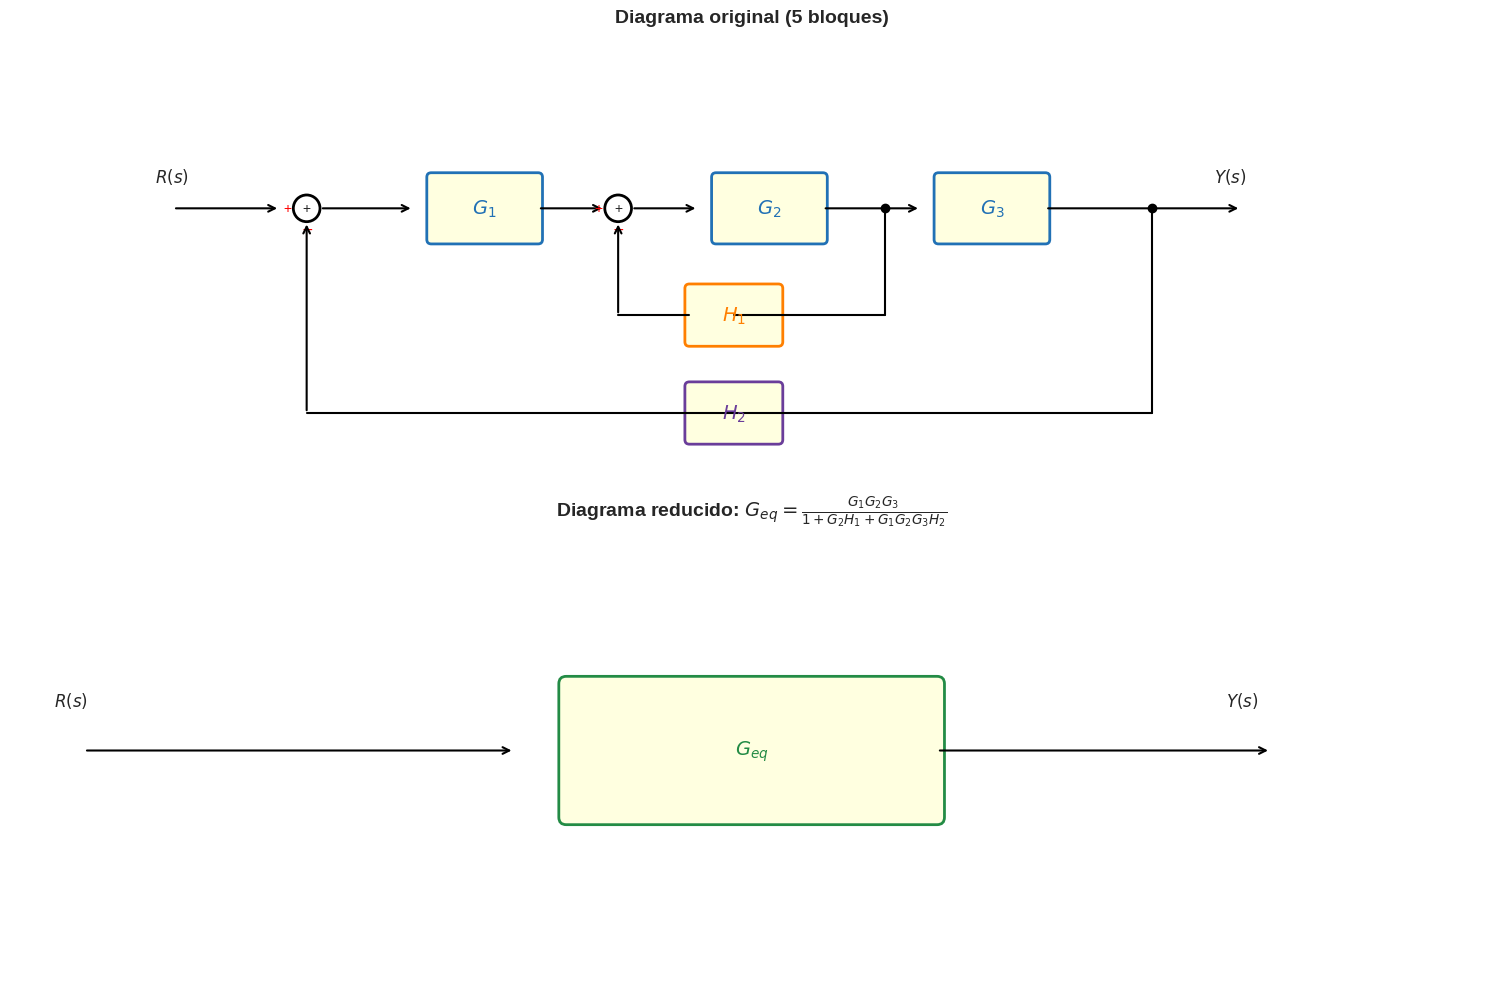

In [8]:
# Diagrama de bloques complejo (5 bloques) y su reducción
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# --- Diagrama original ---
ax = axes[0]
ax.set_xlim(-1, 13)
ax.set_ylim(-2.5, 2.5)
ax.set_title('Diagrama original (5 bloques)', fontsize=14, fontweight='bold')

# Entrada
draw_arrow(ax, -0.5, 0.5, 0.7, 0.5)
ax.text(-0.7, 0.8, r'$R(s)$', fontsize=12)

# Sumador de entrada
draw_sumador(ax, 1, 0.5, signs={'left': '+', 'bottom': '$-$'})

# G1
draw_arrow(ax, 1.15, 0.5, 2.2, 0.5)
draw_block(ax, 3, 0.5, 1.2, 0.7, r'$G_1$')

# Sumador interno
draw_arrow(ax, 3.6, 0.5, 4.35, 0.5)
draw_sumador(ax, 4.5, 0.5, signs={'left': '+', 'bottom': '$-$'})

# G2
draw_arrow(ax, 4.65, 0.5, 5.4, 0.5)
draw_block(ax, 6.2, 0.5, 1.2, 0.7, r'$G_2$')

# G3
draw_arrow(ax, 6.8, 0.5, 7.9, 0.5)
draw_block(ax, 8.7, 0.5, 1.2, 0.7, r'$G_3$')

# Salida
draw_arrow(ax, 9.3, 0.5, 11.5, 0.5)
ax.text(11.2, 0.8, r'$Y(s)$', fontsize=12)

# Bifurcación tras G2
ax.plot(7.5, 0.5, 'ko', ms=6)

# Realimentación interna H1
ax.plot([7.5, 7.5], [0.5, -0.7], 'k-', lw=1.5)
ax.plot([7.5, 5.8], [-0.7, -0.7], 'k-', lw=1.5)
draw_block(ax, 5.8, -0.7, 1.0, 0.6, r'$H_1$', color=COLOR_AUX)
ax.plot([5.3, 4.5], [-0.7, -0.7], 'k-', lw=1.5)
draw_arrow(ax, 4.5, -0.7, 4.5, 0.35)

# Bifurcación de salida
ax.plot(10.5, 0.5, 'ko', ms=6)

# Realimentación externa H2
ax.plot([10.5, 10.5], [0.5, -1.8], 'k-', lw=1.5)
ax.plot([10.5, 1.0], [-1.8, -1.8], 'k-', lw=1.5)
draw_block(ax, 5.8, -1.8, 1.0, 0.6, r'$H_2$', color=COLOR_AUX2)
draw_arrow(ax, 1.0, -1.8, 1.0, 0.35)

ax.set_aspect('equal')
ax.axis('off')

# --- Diagrama reducido ---
ax = axes[1]
ax.set_xlim(-1, 9)
ax.set_ylim(-1, 2)
ax.set_title(r'Diagrama reducido: $G_{eq} = \frac{G_1 G_2 G_3}{1 + G_2 H_1 + G_1 G_2 G_3 H_2}$',
             fontsize=14, fontweight='bold')

draw_arrow(ax, -0.5, 0.5, 2.4, 0.5)
ax.text(-0.7, 0.8, r'$R(s)$', fontsize=12)
draw_block(ax, 4, 0.5, 2.5, 0.9, r'$G_{eq}$', color=COLOR_PUNTO)
draw_arrow(ax, 5.25, 0.5, 7.5, 0.5)
ax.text(7.2, 0.8, r'$Y(s)$', fontsize=12)
ax.set_aspect('equal')
ax.axis('off')

plt.tight_layout()
plt.show()

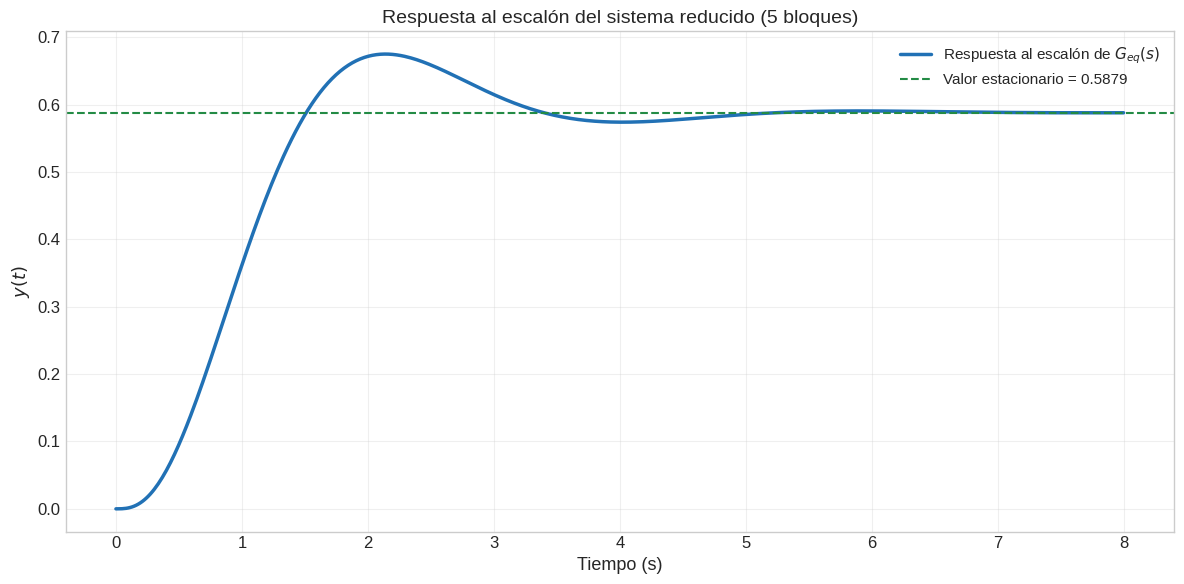

In [9]:
# Verificación numérica: reducción del diagrama de 5 bloques con scipy.signal
# G1 = 2/(s+1), G2 = 1/(s+3), G3 = 5/(s+2), H1 = 0.5, H2 = 1

G1 = signal.TransferFunction([2], [1, 1])
G2 = signal.TransferFunction([1], [1, 3])
G3 = signal.TransferFunction([5], [1, 2])

# Paso 1: Lazo interno G2/(1 + 0.5*G2)
# G2*H1 = 0.5/(s+3), entonces 1 + G2*H1 = (s+3.5)/(s+3)
# G_int = (1/(s+3)) / ((s+3.5)/(s+3)) = 1/(s+3.5)
G_int = signal.TransferFunction([1], [1, 3.5])

# Paso 2: Serie G1 * G_int * G3
# = 2/(s+1) * 1/(s+3.5) * 5/(s+2) = 10/((s+1)(s+3.5)(s+2))
num_dir = np.polymul(np.polymul([2], [1]), [5])  # = [10]
den_dir = np.polymul(np.polymul([1, 1], [1, 3.5]), [1, 2])
G_dir = signal.TransferFunction(num_dir, den_dir)

# Paso 3: Lazo externo G_dir/(1 + G_dir) (H2=1)
# num_eq = 10, den_eq = (s+1)(s+3.5)(s+2) + 10
den_eq = np.polyadd(den_dir, num_dir)
G_eq = signal.TransferFunction(num_dir, den_eq)

t_eq, y_eq = signal.step(G_eq, T=np.linspace(0, 8, 500))

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(t_eq, y_eq, color=COLOR_PRINCIPAL, lw=2.5,
        label=r'Respuesta al escalón de $G_{eq}(s)$')
ax.axhline(y=y_eq[-1], color=COLOR_PUNTO, ls='--', lw=1.5,
           label=f'Valor estacionario = {y_eq[-1]:.4f}')
ax.set_xlabel('Tiempo (s)')
ax.set_ylabel(r'$y(t)$')
ax.set_title('Respuesta al escalón del sistema reducido (5 bloques)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## 7. Ejercicios resueltos

### 7.1 Ejercicio resuelto: Masa-resorte-amortiguador $\to$ EDO $\to$ FT

#### Ejercicio resuelto: Sistema mecánico

**Datos:** $m = 1$ kg, $b = 4$ N$\cdot$s/m, $k = 3$ N/m. Entrada: fuerza $F(t)$. Salida: desplazamiento $x(t)$.

**Paso 1:** Aplicar 2ª Ley de Newton:

$$F(t) - b\dot{x} - kx = m\ddot{x}$$

$$m\ddot{x} + b\dot{x} + kx = F(t)$$

$$1\cdot\ddot{x} + 4\dot{x} + 3x = F(t)$$

**Paso 2:** Aplicar Laplace (c.i. nulas):

$$s^2X(s) + 4sX(s) + 3X(s) = F(s)$$

$$X(s)(s^2 + 4s + 3) = F(s)$$

**Paso 3:** Función de transferencia:

$$\boxed{G(s) = \frac{X(s)}{F(s)} = \frac{1}{s^2 + 4s + 3} = \frac{1}{(s+1)(s+3)}}$$

**Paso 4:** Verificación. Polos: $s_1 = -1$, $s_2 = -3$ (ambos reales negativos $\to$ sistema **estable** y **sobreamortiguado**).

Ganancia estática: $G(0) = \dfrac{1}{3} = 0.333$ m/N.

### 7.2 Ejercicio resuelto: Circuito RLC serie $\to$ EDO $\to$ FT

#### Ejercicio resuelto: Sistema eléctrico

**Datos:** $R = 20\;\Omega$, $L = 1$ H, $C = 0.02$ F. Entrada: $v_{in}(t)$. Salida: $v_C(t)$.

**Paso 1:** LKV en el lazo:

$$v_{in} = v_R + v_L + v_C = Ri + L\frac{di}{dt} + v_C$$

Como $i = C\dfrac{dv_C}{dt}$:

$$v_{in} = RC\dot{v}_C + LC\ddot{v}_C + v_C$$

$$0.02\ddot{v}_C + 0.4\dot{v}_C + v_C = v_{in}$$

**Paso 2:** Laplace:

$$0.02s^2V_C(s) + 0.4sV_C(s) + V_C(s) = V_{in}(s)$$

**Paso 3:** Función de transferencia:

$$G(s) = \frac{V_C(s)}{V_{in}(s)} = \frac{1}{0.02s^2 + 0.4s + 1}$$

$$\boxed{G(s) = \frac{50}{s^2 + 20s + 50}}$$

**Paso 4:** Polos: $s = \frac{-20 \pm \sqrt{400 - 200}}{2} = \frac{-20 \pm 14.14}{2}$

$$s_1 = -2.93 \qquad s_2 = -17.07$$

Ambos polos reales negativos $\to$ sistema **estable sobreamortiguado**.

Ganancia estática: $G(0) = \dfrac{50}{50} = 1$ (la tensión del condensador alcanza la tensión de entrada).

### 7.3 Ejercicio resuelto: Linealización de un sistema de nivel de tanque

#### Ejercicio resuelto: Linealización hidráulica

**Datos:** Tanque de sección $A = 1$ m$^2$, salida por orificio: $q_{out} = c\sqrt{h}$ con $c = 0.5$ m$^{5/2}$/s. Punto de operación: $q_{in,eq} = 1$ m$^3$/s.

**Paso 1:** EDO no lineal:

$$A\frac{dh}{dt} = q_{in} - c\sqrt{h}$$

**Paso 2:** Punto de equilibrio ($\dot{h} = 0$):

$$q_{in,eq} = c\sqrt{h_{eq}} \implies h_{eq} = \left(\frac{q_{in,eq}}{c}\right)^2 = \left(\frac{1}{0.5}\right)^2 = 4\;\text{m}$$

**Paso 3:** Linealización. Sea $f(h, q_{in}) = q_{in} - c\sqrt{h}$:

$$\frac{\partial f}{\partial h}\bigg|_{eq} = -\frac{c}{2\sqrt{h_{eq}}} = -\frac{0.5}{2\sqrt{4}} = -\frac{0.5}{4} = -0.125\;\text{s}^{-1}$$

$$\frac{\partial f}{\partial q_{in}}\bigg|_{eq} = 1$$

**Paso 4:** EDO linealizada ($\delta h = h - h_{eq}$, $\delta q = q_{in} - q_{in,eq}$):

$$A\frac{d(\delta h)}{dt} = -0.125\cdot\delta h + 1\cdot\delta q$$

$$1\cdot\delta\dot{h} + 0.125\cdot\delta h = \delta q$$

**Paso 5:** Función de transferencia:

$$s\Delta H(s) + 0.125\Delta H(s) = \Delta Q(s)$$

$$\boxed{G(s) = \frac{\Delta H(s)}{\Delta Q(s)} = \frac{1}{s + 0.125}}$$

Constante de tiempo: $\tau = \dfrac{1}{0.125} = 8$ s. Ganancia estática: $G(0) = 8$ m/(m$^3$/s).

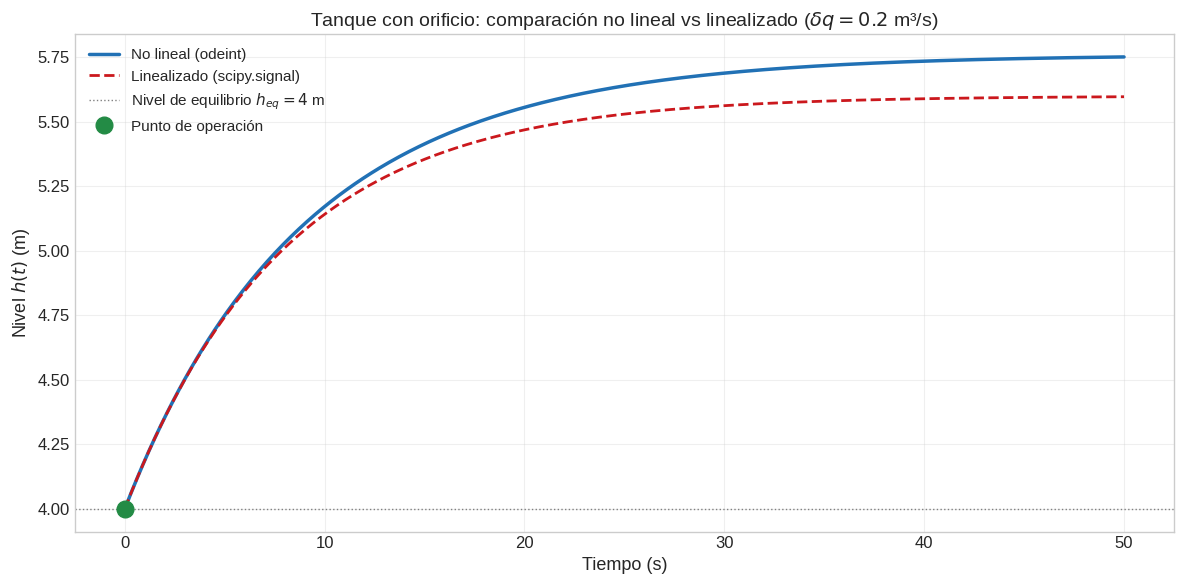

In [10]:
# Comparación: respuesta no lineal vs linealizada del tanque
A_t, c_t = 1.0, 0.5
q_in_eq = 1.0
h_eq = (q_in_eq / c_t)**2  # = 4 m

# Respuesta no lineal (odeint)
def tanque_no_lineal(h, t, q_in):
    return (q_in - c_t * np.sqrt(max(h, 0))) / A_t

# Respuesta linealizada: G(s) = 1/(s + 0.125), escalón de δq = 0.2
delta_q = 0.2
sys_tank = signal.TransferFunction([1], [1, 0.125])
t_lin = np.linspace(0, 50, 500)
_, y_lin = signal.step(sys_tank, T=t_lin)
h_lin = h_eq + delta_q * y_lin  # reescalar por amplitud del escalón

# Respuesta no lineal
q_in_new = q_in_eq + delta_q
h_nl = odeint(tanque_no_lineal, h_eq, t_lin, args=(q_in_new,)).flatten()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(t_lin, h_nl, color=COLOR_PRINCIPAL, lw=2.5, label='No lineal (odeint)')
ax.plot(t_lin, h_lin, color=COLOR_RECTA, lw=2, ls='--', label='Linealizado (scipy.signal)')
ax.axhline(y=h_eq, color='gray', ls=':', lw=1, label=f'Nivel de equilibrio $h_{{eq}} = {h_eq:.0f}$ m')
ax.plot(0, h_eq, 'o', color=COLOR_PUNTO, ms=12, zorder=5, label='Punto de operación')

ax.set_xlabel('Tiempo (s)')
ax.set_ylabel(r'Nivel $h(t)$ (m)')
ax.set_title(r'Tanque con orificio: comparación no lineal vs linealizado ($\delta q = 0.2$ m³/s)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 7.4 Ejercicio resuelto: Reducción de diagrama de bloques

#### Ejercicio resuelto: Álgebra de bloques

**Datos:** Sistema con realimentación unitaria negativa. Camino directo: $G_1(s) = \dfrac{10}{s+5}$ en serie con $G_2(s) = \dfrac{1}{s+2}$.

**Paso 1:** Serie de $G_1$ y $G_2$:

$$G_{dir}(s) = G_1 \cdot G_2 = \frac{10}{s+5} \cdot \frac{1}{s+2} = \frac{10}{(s+5)(s+2)} = \frac{10}{s^2 + 7s + 10}$$

**Paso 2:** Cerrar lazo con realimentación unitaria ($H = 1$):

$$G_{eq}(s) = \frac{G_{dir}}{1 + G_{dir}} = \frac{\dfrac{10}{s^2 + 7s + 10}}{1 + \dfrac{10}{s^2 + 7s + 10}}$$

$$G_{eq}(s) = \frac{10}{s^2 + 7s + 10 + 10}$$

$$\boxed{G_{eq}(s) = \frac{10}{s^2 + 7s + 20}}$$

**Paso 3:** Verificación. Polos: $s = \dfrac{-7 \pm \sqrt{49 - 80}}{2} = \dfrac{-7 \pm j\sqrt{31}}{2} = -3.5 \pm j2.78$

Polos complejos conjugados con parte real negativa $\to$ sistema **estable subamortiguado**.

Ganancia estática: $G_{eq}(0) = \dfrac{10}{20} = 0.5$.

### 7.5 Ejercicio resuelto: Circuito RC (primer orden)

#### Ejercicio resuelto: Sistema de primer orden

**Datos:** $R = 1\;\text{k}\Omega$, $C = 100\;\mu\text{F}$. Entrada: $v_{in}(t)$. Salida: $v_C(t)$.

**Paso 1:** LKV:

$$v_{in} = Ri + v_C = RC\frac{dv_C}{dt} + v_C$$

$$RC\dot{v}_C + v_C = v_{in}$$

Con valores: $\tau = RC = 1000 \times 100 \times 10^{-6} = 0.1$ s

$$0.1\dot{v}_C + v_C = v_{in}$$

**Paso 2:** Laplace y FT:

$$0.1sV_C(s) + V_C(s) = V_{in}(s)$$

$$\boxed{G(s) = \frac{V_C(s)}{V_{in}(s)} = \frac{1}{0.1s + 1} = \frac{10}{s + 10}}$$

Polo: $s = -10$ (real negativo $\to$ estable). Constante de tiempo $\tau = 0.1$ s. Ganancia estática $G(0) = 1$.

### 7.6 Ejercicio resuelto: Linealización de sistema térmico con radiación

#### Ejercicio resuelto: Linealización térmica

**Datos:** Cuerpo con capacidad térmica $C_t = 50$ J/K. Entrada: potencia $P(t)$. Pérdidas por radiación: $q_{rad} = \sigma\epsilon A T^4$ (ley de Stefan-Boltzmann). Punto de operación: $T_{eq} = 400$ K, $\sigma\epsilon A = 2 \times 10^{-8}$ W/K$^4$.

**Paso 1:** EDO no lineal:

$$C_t\frac{dT}{dt} = P - \sigma\epsilon A T^4$$

**Paso 2:** Equilibrio ($\dot{T} = 0$):

$$P_{eq} = \sigma\epsilon A T_{eq}^4 = 2 \times 10^{-8} \times 400^4 = 2 \times 10^{-8} \times 2.56 \times 10^{10} = 512\;\text{W}$$

**Paso 3:** Derivadas parciales de $f(T, P) = P - \sigma\epsilon AT^4$:

$$\frac{\partial f}{\partial T}\bigg|_{eq} = -4\sigma\epsilon AT_{eq}^3 = -4 \times 2 \times 10^{-8} \times 400^3 = -4 \times 0.00128 = -5.12\;\text{W/K}$$

$$\frac{\partial f}{\partial P}\bigg|_{eq} = 1$$

**Paso 4:** EDO linealizada:

$$C_t\delta\dot{T} = -5.12\cdot\delta T + \delta P$$

$$50\delta\dot{T} + 5.12\cdot\delta T = \delta P$$

**Paso 5:** Función de transferencia:

$$\boxed{G(s) = \frac{\Delta T(s)}{\Delta P(s)} = \frac{1}{50s + 5.12} = \frac{0.1953}{s + 0.1024}}$$

Constante de tiempo: $\tau = \dfrac{50}{5.12} = 9.77$ s. Ganancia estática: $G(0) = \dfrac{1}{5.12} = 0.195$ K/W.

---

## 8. Catálogo completo de ejercicios: todos los patrones

Esta sección clasifica los 12 tipos de problemas que pueden aparecer en exámenes del Tema 2.

| # | Tipo | Dominio | Ecuación clave | Dificultad |
|---|------|---------|---------------|:----------:|
| 1 | Masa-resorte-amortiguador | Mecánico | $m\ddot{x} + b\dot{x} + kx = F$ | Media |
| 2 | Péndulo (linealización) | Mecánico | $I\ddot{\varphi} + B\dot{\varphi} + mgl\sin\varphi = T$ | Alta |
| 3 | Circuito RC | Eléctrico | $RC\dot{v}_C + v_C = v_{in}$ | Baja |
| 4 | Circuito RL | Eléctrico | $L\dot{i} + Ri = v_{in}$ | Baja |
| 5 | Circuito RLC serie | Eléctrico | $LC\ddot{v}_C + RC\dot{v}_C + v_C = v_{in}$ | Media |
| 6 | Tanque con válvula lineal | Hidráulico | $AR_h\dot{h} + h = R_h q_{in}$ | Baja |
| 7 | Tanque con orificio (linealizar) | Hidráulico | $A\dot{h} = q_{in} - c\sqrt{h}$ | Alta |
| 8 | Cuerpo con convección | Térmico | $C_tR_t\dot{\theta} + \theta = R_tq_{in}$ | Baja |
| 9 | Cuerpo con radiación (linealizar) | Térmico | $C_t\dot{T} = P - \sigma\epsilon AT^4$ | Alta |
| 10 | Reducción serie/paralelo | Bloques | $G_{eq} = G_1 G_2$ o $G_1 + G_2$ | Baja |
| 11 | Reducción con realimentación | Bloques | $G_{eq} = G/(1+GH)$ | Media |
| 12 | Diagrama complejo (múltiples lazos) | Bloques | Combinación de reglas | Alta |

### 8.1 Tipo 1: Masa-resorte-amortiguador

$$\boxed{G(s) = \frac{1}{ms^2 + bs + k}}$$

**Cómo afectan los parámetros:**
- Si **$m$ aumenta** $\to$ oscilaciones más lentas $\to$ frecuencia natural $\omega_n = \sqrt{k/m}$ disminuye
- Si **$b$ aumenta** $\to$ amortiguamiento $\zeta = b/(2\sqrt{mk})$ aumenta $\to$ menos oscilaciones
- Si **$k$ aumenta** $\to$ sistema más rígido $\to$ frecuencia natural aumenta, valor estacionario $1/k$ disminuye

#### Ejercicio resuelto: Tipo 1

**Datos:** $m = 0.5$ kg, $b = 1$ N$\cdot$s/m, $k = 2$ N/m

$$G(s) = \frac{1}{0.5s^2 + s + 2} = \frac{2}{s^2 + 2s + 4}$$

Polos: $s = \dfrac{-2 \pm \sqrt{4-16}}{2} = -1 \pm j\sqrt{3}$

$\omega_n = \sqrt{4} = 2$ rad/s, $\zeta = \dfrac{2}{2 \cdot 2} = 0.5$ (subamortiguado).

Ganancia estática: $G(0) = \dfrac{2}{4} = 0.5$ m/N.

### 8.2 Tipo 2: Péndulo (linealización de $\sin\varphi$)

EDO no lineal: $I\ddot{\varphi} + B\dot{\varphi} + mgl\sin(\varphi) = T$

**Procedimiento:** equilibrio $\to$ Taylor de $\sin$ $\to$ variables incrementales $\to$ cancelación del punto de equilibrio.

$$\boxed{G(s) = \frac{1}{Is^2 + Bs + mgl\cos(\varphi_{eq})}}$$

**Truco para el examen:** la linealización de $\sin(\varphi)$ siempre introduce $\cos(\varphi_{eq})$ como factor del término proporcional. Si $\varphi_{eq} = 0$, $\cos(0) = 1$ y la EDO es idéntica a masa-resorte-amortiguador.

#### Ejercicio resuelto: Tipo 2

**Datos:** $I = 1$ kg$\cdot$m$^2$, $B = 0.5$ N$\cdot$m$\cdot$s/rad, $m = 2$ kg, $l = 0.3$ m, $\varphi_{eq} = \pi/6$ (30°)

$mgl\cos(\varphi_{eq}) = 2 \times 9.81 \times 0.3 \times \cos(30°) = 5.886 \times 0.866 = 5.097$

$$G(s) = \frac{1}{s^2 + 0.5s + 5.097}$$

Polos: $s = \dfrac{-0.5 \pm \sqrt{0.25 - 20.39}}{2} = -0.25 \pm j2.24$ (subamortiguado).

### 8.3 Tipo 3: Circuito RC (1er orden)

$$\boxed{G(s) = \frac{1}{\tau s + 1} = \frac{1/\tau}{s + 1/\tau}} \qquad \tau = RC$$

**Cómo afectan los parámetros:**
- Si **$R$ aumenta** $\to$ $\tau$ aumenta $\to$ respuesta más lenta
- Si **$C$ aumenta** $\to$ $\tau$ aumenta $\to$ respuesta más lenta
- La ganancia estática es **siempre 1** (el condensador se carga hasta $v_{in}$)

#### Ejercicio resuelto: Tipo 3

**Datos:** $R = 4.7\;\text{k}\Omega$, $C = 47\;\mu\text{F}$

$\tau = RC = 4700 \times 47 \times 10^{-6} = 0.221$ s

$$G(s) = \frac{1}{0.221s + 1} = \frac{4.525}{s + 4.525}$$

### 8.4 Tipo 4: Circuito RL (1er orden)

$$\boxed{G(s) = \frac{R}{Ls + R} = \frac{1}{\tau s + 1}} \qquad \tau = L/R$$

Salida: corriente $i(t)$. Entrada: $v_{in}(t)$. La ganancia estática es $1/R$.

#### Ejercicio resuelto: Tipo 4

**Datos:** $R = 100\;\Omega$, $L = 0.2$ H

$\tau = L/R = 0.2/100 = 0.002$ s = 2 ms

$$G(s) = \frac{I(s)}{V_{in}(s)} = \frac{1/L}{s + R/L} = \frac{5}{s + 500}$$

Ganancia estática: $G(0) = 5/500 = 0.01 = 1/R$ A/V.

### 8.5 Tipo 5: Circuito RLC serie (2º orden)

$$\boxed{G(s) = \frac{1}{LCs^2 + RCs + 1} = \frac{\omega_n^2}{s^2 + 2\zeta\omega_n s + \omega_n^2}}$$

donde $\omega_n = \dfrac{1}{\sqrt{LC}}$ y $\zeta = \dfrac{R}{2}\sqrt{\dfrac{C}{L}}$.

**Cómo afectan los parámetros:**
- Si **$R$ aumenta** $\to$ $\zeta$ aumenta $\to$ menos oscilaciones (más amortiguado)
- Si **$L$ aumenta** $\to$ $\omega_n$ disminuye $\to$ respuesta más lenta
- Si **$C$ aumenta** $\to$ $\omega_n$ disminuye $\to$ respuesta más lenta

#### Ejercicio resuelto: Tipo 5

**Datos:** $R = 5\;\Omega$, $L = 0.1$ H, $C = 0.01$ F

$\omega_n = \dfrac{1}{\sqrt{0.1 \times 0.01}} = \dfrac{1}{\sqrt{0.001}} = 31.62$ rad/s

$\zeta = \dfrac{5}{2}\sqrt{\dfrac{0.01}{0.1}} = 2.5 \times 0.316 = 0.791$ (subamortiguado, $\zeta < 1$)

$$G(s) = \frac{1000}{s^2 + 50s + 1000}$$

Polos: $s = \dfrac{-50 \pm \sqrt{2500 - 4000}}{2} = -25 \pm j27.39$

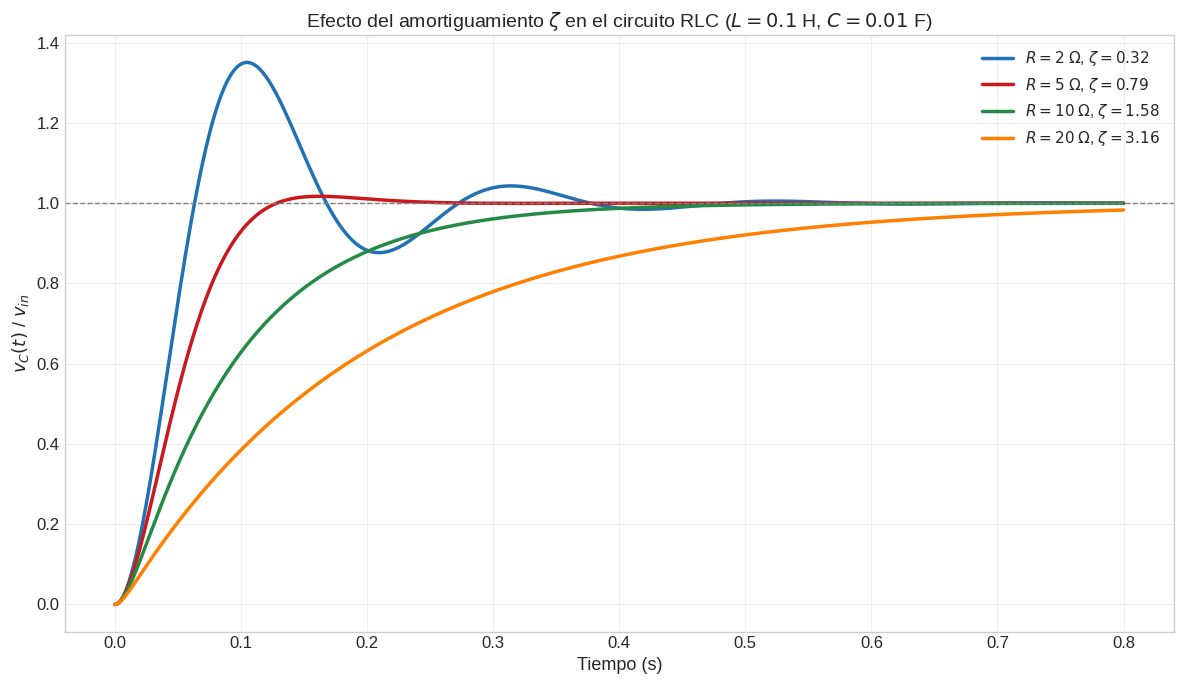

In [11]:
# Efecto del amortiguamiento en circuito RLC (variando R)
fig, ax = plt.subplots(figsize=(12, 7))
L_val, C_val = 0.1, 0.01
omega_n = 1 / np.sqrt(L_val * C_val)

R_vals = [2, 5, 10, 20]
colors = [COLOR_PRINCIPAL, COLOR_RECTA, COLOR_PUNTO, COLOR_AUX]
t_plot = np.linspace(0, 0.8, 500)

for R_val, color in zip(R_vals, colors):
    zeta = (R_val / 2) * np.sqrt(C_val / L_val)
    sys_i = signal.TransferFunction([omega_n**2], [1, 2*zeta*omega_n, omega_n**2])
    _, y_i = signal.step(sys_i, T=t_plot)
    ax.plot(t_plot, y_i, color=color, lw=2.5,
            label=f'$R = {R_val}\\;\\Omega$, $\\zeta = {zeta:.2f}$')

ax.axhline(y=1.0, color='gray', ls='--', lw=1)
ax.set_xlabel('Tiempo (s)')
ax.set_ylabel(r'$v_C(t)$ / $v_{in}$')
ax.set_title(r'Efecto del amortiguamiento $\zeta$ en el circuito RLC ($L=0.1$ H, $C=0.01$ F)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 8.6 Tipo 6: Tanque con válvula lineal (1er orden)

$$\boxed{G(s) = \frac{R_h}{\tau s + 1}} \qquad \tau = AR_h$$

**Cómo afectan los parámetros:**
- Si **$A$ aumenta** (tanque más grande) $\to$ $\tau$ aumenta $\to$ respuesta más lenta
- Si **$R_h$ aumenta** (válvula más cerrada) $\to$ $\tau$ aumenta Y ganancia estática aumenta $\to$ nivel final más alto

#### Ejercicio resuelto: Tipo 6

**Datos:** $A = 3$ m$^2$, $R_h = 2$ m/(m$^3$/s)

$\tau = AR_h = 3 \times 2 = 6$ s

$$G(s) = \frac{2}{6s + 1} = \frac{1/3}{s + 1/6}$$

Ganancia estática: $G(0) = 2$ m/(m$^3$/s). Si $q_{in} = 0.5$ m$^3$/s $\to$ $h_{eq} = 2 \times 0.5 = 1$ m.

### 8.7 Tipo 7: Tanque con orificio (linealización de $\sqrt{h}$)

EDO no lineal: $A\dot{h} = q_{in} - c\sqrt{h}$

**Procedimiento:** encontrar $h_{eq}$, derivar $\sqrt{h}$ respecto a $h$, obtener resistencia hidráulica equivalente.

$$\frac{d}{dh}\left(c\sqrt{h}\right)\bigg|_{h_{eq}} = \frac{c}{2\sqrt{h_{eq}}} = \frac{1}{R_{h,lin}}$$

$$\boxed{G(s) = \frac{R_{h,lin}}{AR_{h,lin}s + 1}} \qquad R_{h,lin} = \frac{2\sqrt{h_{eq}}}{c} = \frac{2h_{eq}}{q_{in,eq}}$$

**Truco para el examen:** la resistencia hidráulica linealizada se puede escribir como $R_{h,lin} = 2h_{eq}/q_{out,eq}$.

#### Ejercicio resuelto: Tipo 7

**Datos:** $A = 2$ m$^2$, $c = 0.3$ m$^{5/2}$/s, $q_{in,eq} = 0.6$ m$^3$/s

$h_{eq} = (q_{in,eq}/c)^2 = (0.6/0.3)^2 = 4$ m

$R_{h,lin} = \dfrac{2\sqrt{4}}{0.3} = \dfrac{4}{0.3} = 13.33$ m/(m$^3$/s)

$\tau = AR_{h,lin} = 2 \times 13.33 = 26.67$ s

$$G(s) = \frac{13.33}{26.67s + 1} = \frac{0.5}{s + 0.0375}$$

### 8.8 Tipo 8: Cuerpo con convección (1er orden)

$$\boxed{G(s) = \frac{R_t}{C_tR_ts + 1}} \qquad \tau = C_tR_t = mc_pR_t$$

#### Ejercicio resuelto: Tipo 8

**Datos:** $m = 0.5$ kg, $c_p = 400$ J/(kg$\cdot$K), $R_t = 0.1$ K/W

$C_t = mc_p = 200$ J/K, $\tau = C_tR_t = 200 \times 0.1 = 20$ s

$$G(s) = \frac{0.1}{20s + 1} = \frac{0.005}{s + 0.05}$$

Ganancia estática: $G(0) = 0.1$ K/W. Si $q_{in} = 50$ W $\to$ $\theta_{eq} = 0.1 \times 50 = 5$ K.

### 8.9 Tipo 9: Cuerpo con radiación (linealización de $T^4$)

EDO no lineal: $C_t\dot{T} = P - \sigma\epsilon AT^4$

$$\frac{d}{dT}(\sigma\epsilon AT^4)\bigg|_{T_{eq}} = 4\sigma\epsilon AT_{eq}^3 = \frac{1}{R_{t,lin}}$$

$$\boxed{G(s) = \frac{R_{t,lin}}{C_tR_{t,lin}s + 1}} \qquad R_{t,lin} = \frac{1}{4\sigma\epsilon AT_{eq}^3}$$

#### Ejercicio resuelto: Tipo 9

**Datos:** $C_t = 100$ J/K, $\sigma\epsilon A = 5 \times 10^{-9}$ W/K$^4$, $T_{eq} = 500$ K

$R_{t,lin} = \dfrac{1}{4 \times 5 \times 10^{-9} \times 500^3} = \dfrac{1}{4 \times 5 \times 10^{-9} \times 1.25 \times 10^8} = \dfrac{1}{2.5} = 0.4$ K/W

$\tau = C_tR_{t,lin} = 100 \times 0.4 = 40$ s

$$G(s) = \frac{0.4}{40s + 1} = \frac{0.01}{s + 0.025}$$

### 8.10 Tipo 10: Reducción serie/paralelo

**Serie:** $G_{eq} = G_1 \cdot G_2 = \dfrac{N_1 N_2}{D_1 D_2}$

**Paralelo:** $G_{eq} = G_1 + G_2 = \dfrac{N_1 D_2 + N_2 D_1}{D_1 D_2}$

#### Ejercicio resuelto: Tipo 10

**Datos:** $G_1(s) = \dfrac{3}{s+1}$, $G_2(s) = \dfrac{2}{s+4}$

**Serie:**

$$G_{serie} = \frac{3}{s+1} \cdot \frac{2}{s+4} = \frac{6}{(s+1)(s+4)} = \frac{6}{s^2 + 5s + 4}$$

**Paralelo:**

$$G_{paralelo} = \frac{3}{s+1} + \frac{2}{s+4} = \frac{3(s+4) + 2(s+1)}{(s+1)(s+4)} = \frac{5s + 14}{s^2 + 5s + 4}$$

### 8.11 Tipo 11: Reducción con realimentación

$$\boxed{G_{eq} = \frac{G}{1 + GH}}$$

#### Ejercicio resuelto: Tipo 11

**Datos:** $G(s) = \dfrac{K}{s(s+a)}$, $H(s) = 1$ (realimentación unitaria), $K = 10$, $a = 3$

$$G_{eq} = \frac{\dfrac{10}{s(s+3)}}{1 + \dfrac{10}{s(s+3)}} = \frac{10}{s(s+3) + 10} = \frac{10}{s^2 + 3s + 10}$$

Polos: $s = \dfrac{-3 \pm \sqrt{9 - 40}}{2} = -1.5 \pm j2.78$ (estable, subamortiguado).

### 8.12 Tipo 12: Diagrama complejo (múltiples lazos)

**Estrategia general:**
1. Identificar los lazos de realimentación (del más interno al más externo)
2. Reducir cada lazo interno primero
3. Combinar bloques en serie
4. Cerrar el lazo externo

**Error frecuente:** olvidar que al mover un punto de bifurcación hay que compensar con un bloque $1/G$ o $G$.

#### Ejercicio resuelto: Tipo 12

**Datos:** $G_1 = \dfrac{2}{s+1}$, $G_2 = \dfrac{3}{s+2}$, $G_3 = \dfrac{1}{s+4}$. $G_2$ y $G_3$ en paralelo, el resultado en serie con $G_1$, todo con realimentación unitaria negativa.

**Paso 1:** Paralelo de $G_2$ y $G_3$:

$$G_{par} = G_2 + G_3 = \frac{3}{s+2} + \frac{1}{s+4} = \frac{3(s+4) + (s+2)}{(s+2)(s+4)} = \frac{4s + 14}{s^2 + 6s + 8}$$

**Paso 2:** Serie con $G_1$:

$$G_{dir} = G_1 \cdot G_{par} = \frac{2}{s+1} \cdot \frac{4s+14}{s^2+6s+8} = \frac{2(4s+14)}{(s+1)(s^2+6s+8)} = \frac{8s+28}{s^3+7s^2+14s+8}$$

**Paso 3:** Realimentación unitaria:

$$G_{eq} = \frac{G_{dir}}{1 + G_{dir}} = \frac{8s+28}{s^3+7s^2+14s+8+8s+28}$$

$$\boxed{G_{eq} = \frac{8s + 28}{s^3 + 7s^2 + 22s + 36}}$$

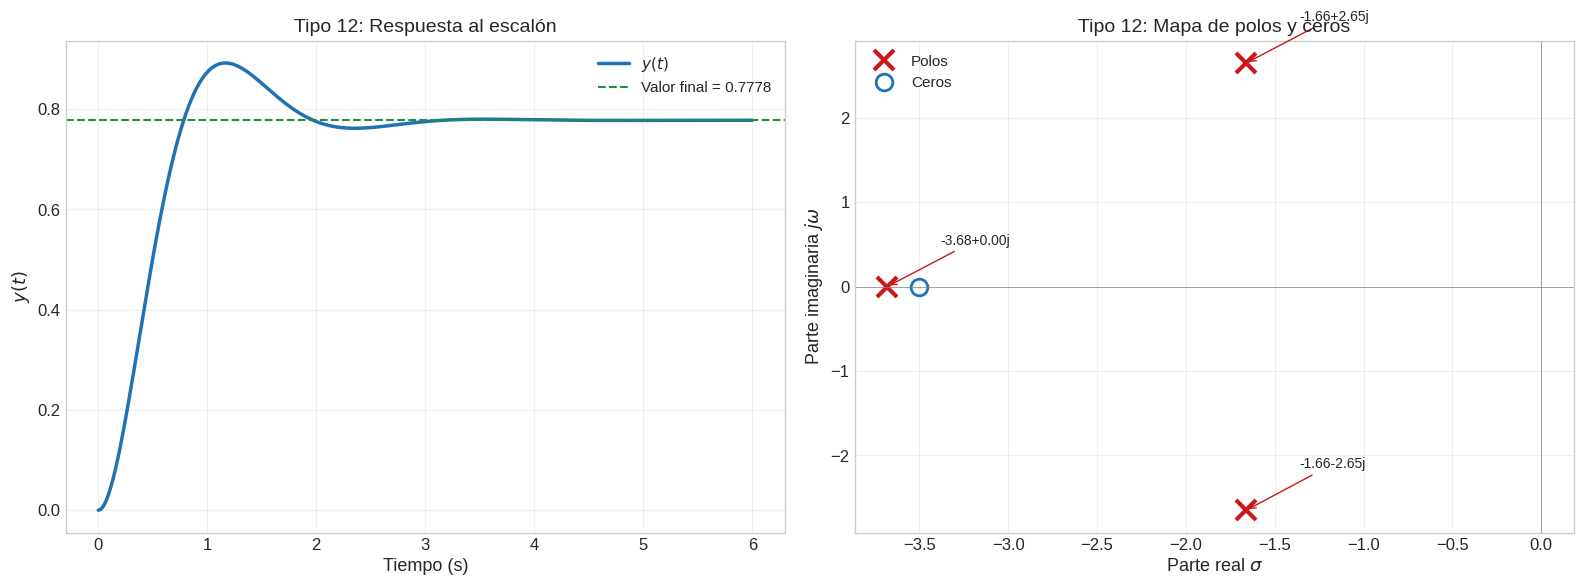

In [12]:
# Verificación del Tipo 12: respuesta al escalón del diagrama complejo reducido
num_t12 = [8, 28]
den_t12 = [1, 7, 22, 36]
sys_t12 = signal.TransferFunction(num_t12, den_t12)
t_t12, y_t12 = signal.step(sys_t12, T=np.linspace(0, 6, 500))

# Polos
polos_t12 = np.roots(den_t12)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Respuesta al escalón
axes[0].plot(t_t12, y_t12, color=COLOR_PRINCIPAL, lw=2.5, label=r'$y(t)$')
axes[0].axhline(y=28/36, color=COLOR_PUNTO, ls='--', lw=1.5,
                label=f'Valor final = {28/36:.4f}')
axes[0].set_xlabel('Tiempo (s)')
axes[0].set_ylabel(r'$y(t)$')
axes[0].set_title('Tipo 12: Respuesta al escalón')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Mapa de polos
axes[1].plot(polos_t12.real, polos_t12.imag, 'x', color=COLOR_RECTA, ms=14, mew=3, label='Polos')
# Ceros
ceros_t12 = np.roots(num_t12)
axes[1].plot(ceros_t12.real, ceros_t12.imag, 'o', color=COLOR_PRINCIPAL, ms=12, mew=2,
             fillstyle='none', label='Ceros')
axes[1].axhline(y=0, color='gray', lw=0.5)
axes[1].axvline(x=0, color='gray', lw=0.5)
for p in polos_t12:
    axes[1].annotate(f'{p:.2f}', xy=(p.real, p.imag),
                     xytext=(p.real + 0.3, p.imag + 0.5), fontsize=10,
                     arrowprops=dict(arrowstyle='->', color=COLOR_RECTA))
axes[1].set_xlabel(r'Parte real $\sigma$')
axes[1].set_ylabel(r'Parte imaginaria $j\omega$')
axes[1].set_title('Tipo 12: Mapa de polos y ceros')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Tabla resumen de fórmulas del catálogo

| Tipo | Dominio | FT en forma estándar | Ganancia estática |
|:---:|:---:|:---:|:---:|
| 1. Masa-resorte-amort. | Mecánico | $\dfrac{1}{ms^2+bs+k}$ | $1/k$ |
| 2. Péndulo | Mecánico | $\dfrac{1}{Is^2+Bs+mgl\cos\varphi_{eq}}$ | $\dfrac{1}{mgl\cos\varphi_{eq}}$ |
| 3. RC | Eléctrico | $\dfrac{1}{RCs+1}$ | $1$ |
| 4. RL | Eléctrico | $\dfrac{1/R}{(L/R)s+1}$ | $1/R$ |
| 5. RLC | Eléctrico | $\dfrac{1}{LCs^2+RCs+1}$ | $1$ |
| 6. Tanque válvula | Hidráulico | $\dfrac{R_h}{AR_hs+1}$ | $R_h$ |
| 7. Tanque orificio | Hidráulico | $\dfrac{R_{h,lin}}{AR_{h,lin}s+1}$ | $R_{h,lin}$ |
| 8. Convección | Térmico | $\dfrac{R_t}{C_tR_ts+1}$ | $R_t$ |
| 9. Radiación | Térmico | $\dfrac{R_{t,lin}}{C_tR_{t,lin}s+1}$ | $R_{t,lin}$ |
| 10. Serie | Bloques | $G_1 G_2$ | $G_1(0)G_2(0)$ |
| 11. Realimentación | Bloques | $\dfrac{G}{1+GH}$ | $\dfrac{G(0)}{1+G(0)H(0)}$ |
| 12. Diagrama complejo | Bloques | Según reducción | Evaluar en $s=0$ |

---

## 9. Formulario de linealización: funciones no lineales comunes

| Función no lineal $f(x)$ | Derivada $f'(x)$ | Linealización alrededor de $x_{eq}$ |
|:---:|:---:|:---:|
| $\sin(x)$ | $\cos(x)$ | $\sin(x_{eq}) + \cos(x_{eq})\cdot\delta x$ |
| $\cos(x)$ | $-\sin(x)$ | $\cos(x_{eq}) - \sin(x_{eq})\cdot\delta x$ |
| $\sqrt{x}$ | $\dfrac{1}{2\sqrt{x}}$ | $\sqrt{x_{eq}} + \dfrac{1}{2\sqrt{x_{eq}}}\cdot\delta x$ |
| $x^2$ | $2x$ | $x_{eq}^2 + 2x_{eq}\cdot\delta x$ |
| $x^n$ | $nx^{n-1}$ | $x_{eq}^n + nx_{eq}^{n-1}\cdot\delta x$ |
| $e^x$ | $e^x$ | $e^{x_{eq}}(1 + \delta x)$ |
| $\ln(x)$ | $1/x$ | $\ln(x_{eq}) + \dfrac{1}{x_{eq}}\cdot\delta x$ |
| $x \cdot y$ (dos variables) | $\dfrac{\partial}{\partial x} = y$, $\dfrac{\partial}{\partial y} = x$ | $x_{eq}y_{eq} + y_{eq}\delta x + x_{eq}\delta y$ |

**Regla general:** $f(x) \approx f(x_{eq}) + f'(x_{eq}) \cdot (x - x_{eq})$

---

## 10. Resumen y tabla de fórmulas clave

| # | Sistema | EDO | Función de transferencia | Orden |
|---|---------|-----|-------------------------|:-----:|
| 1 | Masa-resorte-amort. | $m\ddot{x}+b\dot{x}+kx=F$ | $\dfrac{1}{ms^2+bs+k}$ | 2 |
| 2 | Péndulo linealizado | $I\delta\ddot\varphi+B\delta\dot\varphi+mgl\cos\varphi_{eq}\delta\varphi=\delta T$ | $\dfrac{1}{Is^2+Bs+mgl\cos\varphi_{eq}}$ | 2 |
| 3 | Circuito RC | $RC\dot{v}_C+v_C=v_{in}$ | $\dfrac{1}{RCs+1}$ | 1 |
| 4 | Circuito RL | $L\dot{i}+Ri=v_{in}$ | $\dfrac{1/R}{(L/R)s+1}$ | 1 |
| 5 | Circuito RLC | $LC\ddot{v}_C+RC\dot{v}_C+v_C=v_{in}$ | $\dfrac{1}{LCs^2+RCs+1}$ | 2 |
| 6 | Tanque + válvula | $AR_h\dot{h}+h=R_hq_{in}$ | $\dfrac{R_h}{AR_hs+1}$ | 1 |
| 7 | Tanque + orificio | $A\dot{h}=q_{in}-c\sqrt{h}$ (linealizar) | $\dfrac{R_{h,lin}}{AR_{h,lin}s+1}$ | 1 |
| 8 | Térmico convección | $C_tR_t\dot\theta+\theta=R_tq_{in}$ | $\dfrac{R_t}{C_tR_ts+1}$ | 1 |
| 9 | Térmico radiación | $C_t\dot{T}=P-\sigma\epsilon AT^4$ (linealizar) | $\dfrac{R_{t,lin}}{C_tR_{t,lin}s+1}$ | 1 |

### Reglas de bloques

| Configuración | Fórmula |
|:---:|:---:|
| Serie | $G_{eq} = G_1 \cdot G_2$ |
| Paralelo | $G_{eq} = G_1 + G_2$ |
| Realim. negativa | $G_{eq} = \dfrac{G}{1+GH}$ |
| Realim. positiva | $G_{eq} = \dfrac{G}{1-GH}$ |
| Realim. unitaria | $G_{eq} = \dfrac{G}{1+G}$ |

### Conceptos clave para el examen

- **Ganancia estática**: $K = G(0)$ = valor final de la respuesta al escalón unitario
- **Constante de tiempo** ($\tau$): tiempo en alcanzar el 63.2% del valor final (1er orden)
- **Frecuencia natural** ($\omega_n$): frecuencia de oscilación sin amortiguamiento (2º orden)
- **Factor de amortiguamiento** ($\zeta$): determina si hay oscilaciones ($\zeta < 1$) o no ($\zeta \geq 1$)
- **Estabilidad**: todos los polos deben tener parte real negativa